# 01 — Motivating empirical evidence

Creates the motivating empirical figures for the paper.

In [1]:
# !pip -q install pandas numpy matplotlib scikit-learn openpyxl
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

PROJECT_ROOT = "/content/outputs"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
TAB_DIR = os.path.join(PROJECT_ROOT, "tables")
INT_DIR = os.path.join(PROJECT_ROOT, "intermediate")
for d in [PROJECT_ROOT, FIG_DIR, TAB_DIR, INT_DIR]:
    os.makedirs(d, exist_ok=True)

DATA_PATH = "analytic_cohort_for_modeling.csv"
COL_HOSPITAL = "hospital_hash"
COL_BRAND = "brand_hash"
COL_AGE = "age_at_year"
COL_CM = "cm_count"
COL_DT = "total_downtime_hours"
COL_Y = "high_downtime_t_plus_1"
TEST_SIZE_HOSPITALS = 0.25
RANDOM_STATE = 42

,age_band,future_high_burden_rate,n
0,0-1,0.190187,2466
1,2-5,0.249579,5942
2,6-10,0.264604,3749
3,11-15,0.302852,2034
4,16-20,0.282123,358
5,21+,0.184615,260


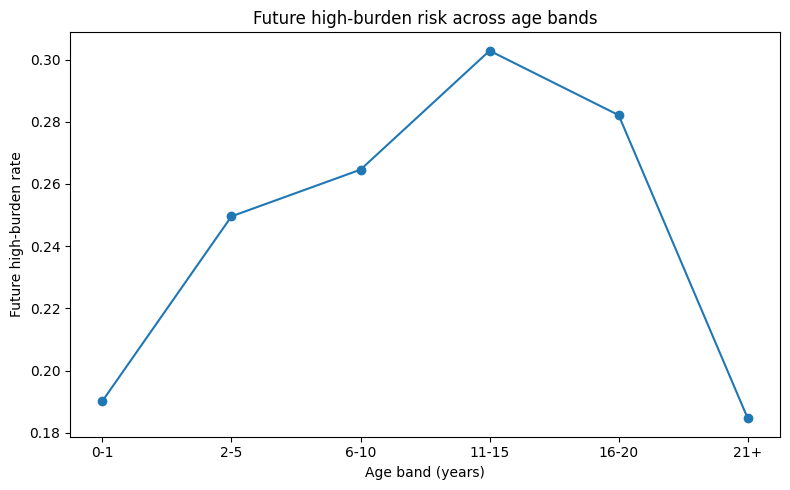

,Group,Share of observations,Future high-burden rate
0,CM = 0,0.595854,0.164098
1,Downtime = 0,0.613681,0.164613
2,CM = 0 and Downtime = 0,0.595854,0.164098


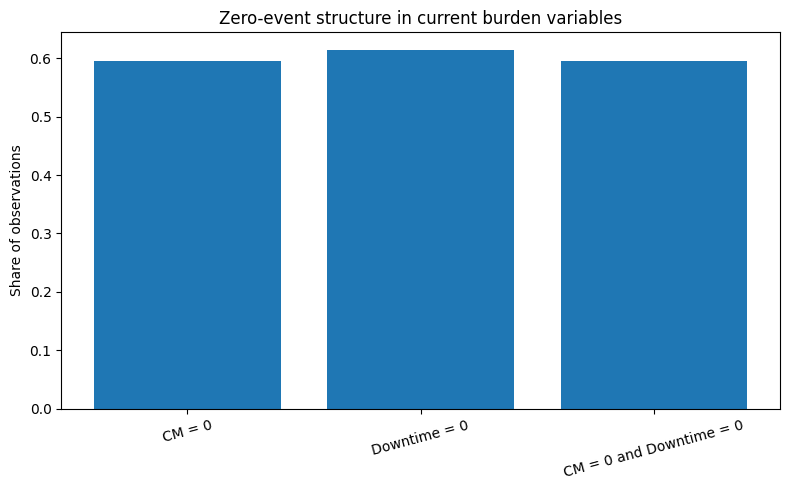

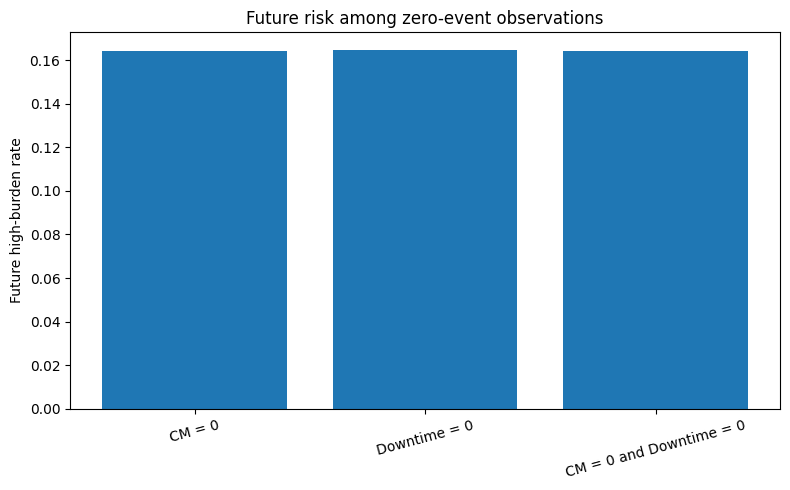

,hospital_hash,future_high_burden_rate,n
13,h_53006a5b1c48,0.000000,137
31,h_d9bb165ee9e3,0.000000,9
30,h_d9120af40e7f,0.022409,357
26,h_c5314c387aed,0.047619,378
35,h_e45bb0661fbd,0.072000,250


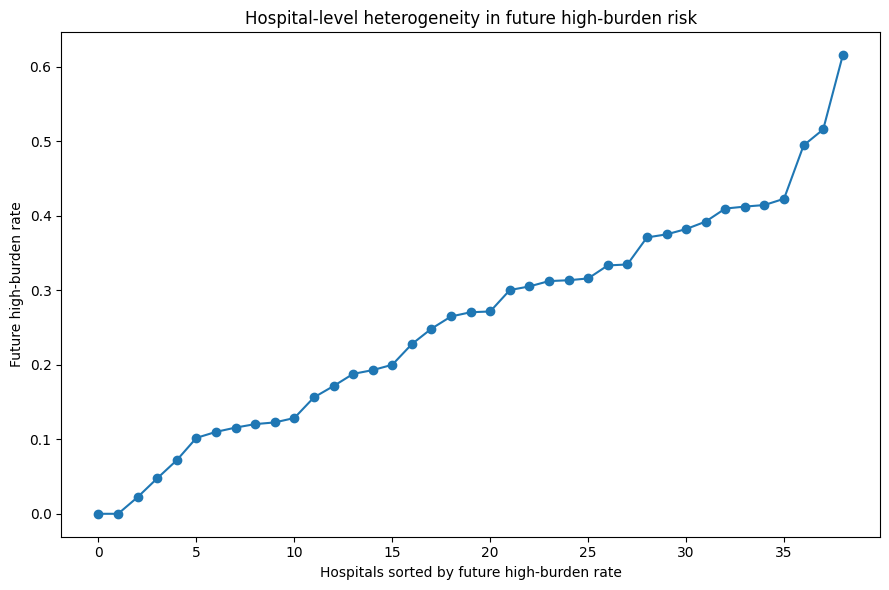

Done.


In [2]:
df = pd.read_csv(DATA_PATH).copy()
bins = [-0.001, 1, 5, 10, 15, 20, np.inf]
labels = ["0-1", "2-5", "6-10", "11-15", "16-20", "21+"]
df["age_band"] = pd.cut(df[COL_AGE], bins=bins, labels=labels)

age_band_risk = (
    df.groupby("age_band", observed=False)[COL_Y]
      .agg(["mean", "count"])
      .reset_index()
      .rename(columns={"mean": "future_high_burden_rate", "count": "n"})
)
display(age_band_risk)
plt.figure(figsize=(8,5))
plt.plot(age_band_risk["age_band"].astype(str), age_band_risk["future_high_burden_rate"], marker="o")
plt.xlabel("Age band (years)")
plt.ylabel("Future high-burden rate")
plt.title("Future high-burden risk across age bands")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_1a_age_band_risk.png"), dpi=300)
plt.show()

zero_summary = pd.DataFrame({
    "Group": ["CM = 0", "Downtime = 0", "CM = 0 and Downtime = 0"],
    "Share of observations": [
        (df[COL_CM] == 0).mean(),
        (df[COL_DT] == 0).mean(),
        ((df[COL_CM] == 0) & (df[COL_DT] == 0)).mean()
    ],
    "Future high-burden rate": [
        df.loc[df[COL_CM] == 0, COL_Y].mean(),
        df.loc[df[COL_DT] == 0, COL_Y].mean(),
        df.loc[(df[COL_CM] == 0) & (df[COL_DT] == 0), COL_Y].mean()
    ]
})
display(zero_summary)

plt.figure(figsize=(8,5))
x = np.arange(len(zero_summary))
plt.bar(x, zero_summary["Share of observations"])
plt.xticks(x, zero_summary["Group"], rotation=15)
plt.ylabel("Share of observations")
plt.title("Zero-event structure in current burden variables")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_1b_zero_event_structure_share.png"), dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(x, zero_summary["Future high-burden rate"])
plt.xticks(x, zero_summary["Group"], rotation=15)
plt.ylabel("Future high-burden rate")
plt.title("Future risk among zero-event observations")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_1b_zero_event_structure_risk.png"), dpi=300)
plt.show()

hospital_risk = (
    df.groupby(COL_HOSPITAL)[COL_Y]
      .agg(["mean", "count"])
      .reset_index()
      .rename(columns={"mean": "future_high_burden_rate", "count": "n"})
      .sort_values("future_high_burden_rate")
)
display(hospital_risk.head())
plt.figure(figsize=(9,6))
plt.plot(np.arange(len(hospital_risk)), hospital_risk["future_high_burden_rate"], marker="o")
plt.xlabel("Hospitals sorted by future high-burden rate")
plt.ylabel("Future high-burden rate")
plt.title("Hospital-level heterogeneity in future high-burden risk")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_1c_hospital_heterogeneity.png"), dpi=300)
plt.show()

age_band_risk.to_csv(os.path.join(TAB_DIR, "table_age_band_risk.csv"), index=False)
zero_summary.to_csv(os.path.join(TAB_DIR, "table_zero_event_structure.csv"), index=False)
hospital_risk.to_csv(os.path.join(TAB_DIR, "table_hospital_risk_summary.csv"), index=False)
print("Done.")